# Training — wait-time models

Two models, trained on the cleaned queue data from `prepare_data.py`:

1. **Live model** — predicts the wait **in 30 minutes** from what is happening now. Used during the day to correct the plan.
2. **Planning model** — predicts the wait at a given time **without** the current queue. Used at entry to plan the whole day.

Every model is compared with a simple **baseline**. If a model can't beat the baseline, it isn't worth using.

In [1]:
# run once if needed, then restart the kernel:
# %pip install xgboost scikit-learn

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

def mean_absolute_error(y_true, y_pred):
    # average error in minutes: mean of |real - predicted|
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

DATA = Path("data") if Path("data").exists() else Path("ml/data")
MODELS = DATA.parent / "models"
MODELS.mkdir(exist_ok=True)
TARGET = "wait_in_30"

BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#9a9a9a"
plt.rcParams.update({
    "figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#888", "axes.grid": True, "grid.color": "#e5e5e5", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "font.size": 10,
})
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
print("xgboost", xgb.__version__)

xgboost 3.4.1


## 1. Load the training file

In [3]:
pq, gz = DATA / "train.parquet", DATA / "train.csv.gz"
df = pd.read_parquet(pq) if pq.exists() else pd.read_csv(gz, parse_dates=["time"])
df["time"] = pd.to_datetime(df["time"])
print(f"{len(df):,} rows, {df['time'].min().date()} to {df['time'].max().date()}")
df.head()

1,411,581 rows, 2018-06-01 to 2022-07-26


,time,park,attraction,attendance,open_rides,attendance_per_ride,hour,minute_of_day,day_of_week,is_weekend,...,wait_prev,guests,capacity,load_ratio,down_min,park_wait_mean,park_wait_change,rides_down,ride_vs_park,wait_in_30
0,2018-06-01 09:15:00,Tivoli Gardens,Aeroplane Ride,"20,420.00",12,"1,701.67",9,555,4,0,...,5.00,95.00,116.25,0.82,0,13.75,NaN,0,-3.75,30.00
1,2018-06-01 09:30:00,Tivoli Gardens,Aeroplane Ride,"20,420.00",12,"1,701.67",9,570,4,0,...,10.00,83.00,116.25,0.71,0,20.00,6.25,0,-5.00,40.00
2,2018-06-01 09:45:00,Tivoli Gardens,Aeroplane Ride,"20,420.00",12,"1,701.67",9,585,4,0,...,15.00,85.00,116.25,0.73,0,27.50,7.50,0,2.50,40.00
3,2018-06-01 10:00:00,Tivoli Gardens,Aeroplane Ride,"20,420.00",12,"1,701.67",10,600,4,0,...,30.00,67.00,116.25,0.58,0,30.00,2.50,0,10.00,40.00
4,2018-06-01 10:15:00,Tivoli Gardens,Aeroplane Ride,"20,420.00",12,"1,701.67",10,615,4,0,...,40.00,78.00,116.25,0.67,0,30.71,0.71,0,9.29,40.00


## 2. Split by time — train on the past, test on the future

We never shuffle. The model learns from older data and is tested on the **most recent year**, which it has never seen.
That is the honest test: at Expo the model always predicts a future it hasn't seen.
July 2020 to June 2021 is held out as **validation** to stop training at the right moment
(the parks were closed for long stretches of 2020-21, so a shorter window would hold almost no data).

In [4]:
TEST_START = pd.Timestamp("2021-07-01")
VAL_START = pd.Timestamp("2020-07-01")   # parks were closed for months in 2020-21 (COVID)

train = df[df["time"] < VAL_START].copy()
val = df[(df["time"] >= VAL_START) & (df["time"] < TEST_START)].copy()
test = df[df["time"] >= TEST_START].copy()
for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:5s} {len(part):>9,} rows  {part['time'].min().date()} to {part['time'].max().date()}")

train   800,749 rows  2018-06-01 to 2020-03-13
val     120,863 rows  2020-07-13 to 2021-06-30
test    489,969 rows  2021-07-01 to 2022-07-26


## 3. Ride characteristics instead of ride names

A ride's **name** means nothing for an Expo pavilion. Its **characteristics** do, and `pavilions.json` has the same ones:

- `ride_popularity` — the ride's usual average wait (like `popularity`)
- `ride_capacity` — the ride's typical capacity per slot (like `capacity_per_hour`)

They are computed **from the training period only**, so no information from the test year leaks in.

In [5]:
ride_stats = train.groupby("attraction").agg(ride_popularity=("wait", "mean"),
                                             ride_capacity=("capacity", "median"))
for part in (train, val, test):
    part[["ride_popularity", "ride_capacity"]] = part[["attraction"]].join(ride_stats, on="attraction")[["ride_popularity", "ride_capacity"]].values
    part["attraction_cat"] = pd.Categorical(part["attraction"], categories=sorted(df["attraction"].unique()))
ride_stats.sort_values("ride_popularity", ascending=False).head(10)

,ride_popularity,ride_capacity
attraction,,
Spiral Slide,73.36,75.00
Monorail,64.21,223.75
Giant Wheel,58.52,503.75
Swing Ride,54.93,242.25
Free Fall,51.62,134.75
Inverted Coaster,50.61,248.60
Scooby Doo,49.53,414.03
Log Flume,43.34,414.75
Reverse Bungee,39.22,127.00


## 4. Baselines — the bar every model must beat

- **Persistence:** the wait in 30 minutes = the wait now. Surprisingly hard to beat.
- **Trend:** continue the last change (now + (now − 15 min ago) × 2).

We report two scores, both in minutes:
- **MAE** — average error on all slots
- **MAE busy** — average error on slots where the real wait is **45+ minutes**. These are the queues Expo needs to avoid, so this score matters most.

In [6]:
def score(y_true, y_pred):
    busy = y_true >= 45
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "MAE busy": mean_absolute_error(y_true[busy], y_pred[busy])}

y_test = test[TARGET].values
results = {}
results["Baseline: persistence"] = score(y_test, test["wait"].values)
results["Baseline: trend"] = score(y_test, (test["wait"] + 2 * (test["wait"] - test["wait_prev"])).clip(0).values)
pd.DataFrame(results).T

,MAE,MAE busy
Baseline: persistence,5.13,8.51
Baseline: trend,8.96,16.72


## 5. Live models — three feature sets

| Set | Uses | Transfers to Expo? |
|---|---|---|
| **A. Full** | queue now + calendar (hour, month) + ride **name** | ❌ name and European hour pattern |
| **B. No clock** | queue now + weekend + ride **name** | ⚠️ name only |
| **C. Transferable** | queue now + weekend + ride **characteristics** + crowd per ride | ✅ everything exists at Expo |

**Every live model predicts the change** (wait in 30 min − wait now) and adds it to the wait now.
If a model learns nothing useful it predicts "no change", which is exactly the persistence baseline, so it can only improve on it.
Models are trained on absolute error, the same measure we score them with.

Raw `attendance` is left out of C on purpose: Expo has ~230,000 visitors a day, far above anything in this data,
and tree models can't extrapolate. **Attendance per ride** (~1,000 per pavilion at Expo) stays inside the range the model learned.

In [7]:
STATE = ["wait", "wait_prev", "guests", "capacity", "load_ratio", "down_min"]
FEATURES = {
    "A. Full":         STATE + ["attendance", "attendance_per_ride", "open_rides", "hour", "minute_of_day",
                                "day_of_week", "is_weekend", "month", "attraction_cat"],
    "B. No clock":     STATE + ["attendance", "attendance_per_ride", "is_weekend", "attraction_cat"],
    "C. Transferable": STATE + ["attendance_per_ride", "is_weekend", "ride_popularity", "ride_capacity"],
        "D. Park-aware":   STATE + ["attendance_per_ride", "is_weekend", "ride_popularity", "ride_capacity",
                                "park_wait_mean", "park_wait_change", "rides_down", "ride_vs_park"],
}

def train_model(feats, target=TARGET, delta=True):
    # delta=True: learn the CHANGE (wait in 30 min - wait now), then add it back to the wait now.
    # If the model learns nothing, it predicts "no change" = the persistence baseline.
    base_tr = train["wait"] if delta else 0
    base_va = val["wait"] if delta else 0
    model = xgb.XGBRegressor(n_estimators=1500, learning_rate=0.05, max_depth=8, subsample=0.8,
                             colsample_bytree=0.8, tree_method="hist", enable_categorical=True,
                             objective="reg:absoluteerror",  # train on the same error we score (MAE)
                             early_stopping_rounds=50, n_jobs=-1, random_state=42)
    model.fit(train[feats], train[target] - base_tr,
              eval_set=[(val[feats], val[target] - base_va)], verbose=False)
    model.feats, model.delta = feats, delta
    return model


def predict(model, X):
    out = model.predict(X[model.feats])
    return (X["wait"].values + out).clip(0) if model.delta else out.clip(0)

live = {}
for name, feats in FEATURES.items():
    live[name] = train_model(feats)
    results[f"Live {name}"] = score(y_test, predict(live[name], test))
    print(f"{name}: done ({live[name].best_iteration + 1} trees)")

live_results = pd.DataFrame(results).T
live_results

A. Full: done (13 trees)
B. No clock: done (10 trees)
C. Transferable: done (6 trees)
D. Park-aware: done (5 trees)


,MAE,MAE busy
Baseline: persistence,5.13,8.51
Baseline: trend,8.96,16.72
Live A. Full,5.14,8.64
Live B. No clock,5.19,8.76
Live C. Transferable,5.19,8.70
Live D. Park-aware,5.18,8.63


In [8]:
change = test["wait_in_30"] - test["wait"]
print(f"no change in 30 min: {(change == 0).mean():.0%}")
print(f"changes by 10+ min: {(change.abs() >= 10).mean():.0%}")
print(change.describe().round(1))

no change in 30 min: 55%
changes by 10+ min: 27%
count   489,969.00
mean         -0.60
std           9.90
min        -225.00
25%           0.00
50%           0.00
75%           0.00
max         235.00
dtype: float64


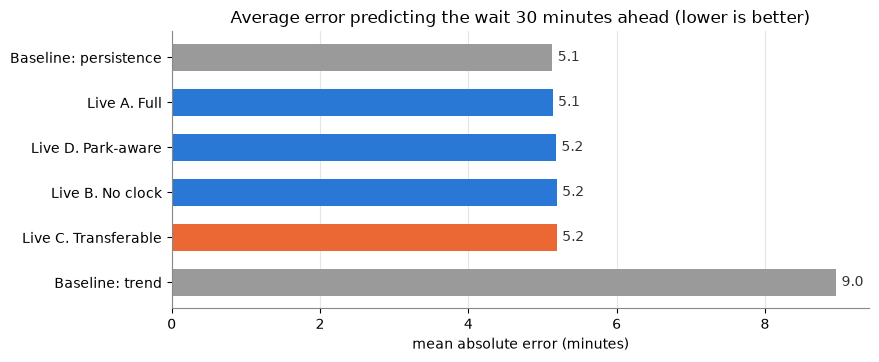

In [9]:
r = live_results.sort_values("MAE", ascending=False)
colors = [GRAY if n.startswith("Baseline") else (ORANGE if "Transferable" in n else BLUE) for n in r.index]
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(r.index, r["MAE"], color=colors, height=0.6)
for i, v in enumerate(r["MAE"]):
    ax.annotate(f"{v:.1f}", (v, i), xytext=(4, 0), textcoords="offset points", va="center", color="#333")
ax.set_title("Average error predicting the wait 30 minutes ahead (lower is better)")
ax.set_xlabel("mean absolute error (minutes)")
ax.grid(axis="y", visible=False)
plt.show()

**Questions:** Do the models beat persistence? How much accuracy does **C** lose compared with **A**?
If the gap is small, C is the one to use at Expo.

## 6. What does the transferable model rely on?

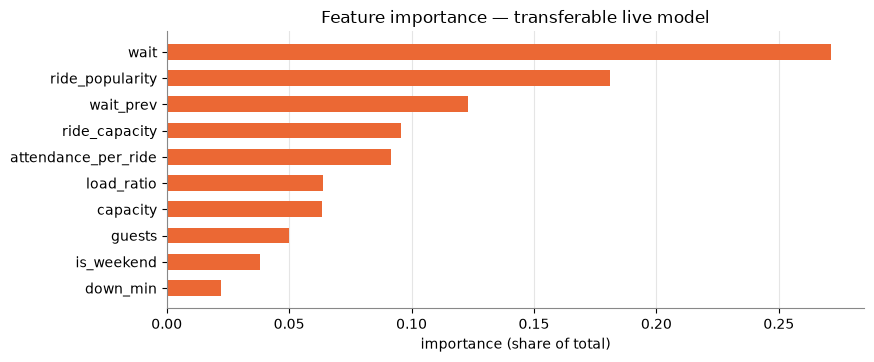

In [10]:
m = live["C. Transferable"]
imp = pd.Series(m.feature_importances_, index=FEATURES["C. Transferable"]).sort_values()
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(imp.index, imp.values, color=ORANGE, height=0.6)
ax.set_title("Feature importance — transferable live model")
ax.set_xlabel("importance (share of total)")
ax.grid(axis="y", visible=False)
plt.show()

## 7. Where is it accurate, where does it struggle?

In [11]:
pred = predict(live["C. Transferable"], test)
t = test.assign(pred=pred, err=np.abs(pred - y_test), base_err=np.abs(test["wait"].values - y_test))
t["bucket"] = pd.cut(t[TARGET], [-1, 15, 30, 45, 60, 90, 300], labels=["0-15", "15-30", "30-45", "45-60", "60-90", "90+"])
by_bucket = t.groupby("bucket", observed=True).agg(slots=("err", "size"), model_MAE=("err", "mean"), persistence_MAE=("base_err", "mean"))
by_bucket

,slots,model_MAE,persistence_MAE
bucket,,,
0-15,218796,3.29,3.26
15-30,120301,5.44,5.41
30-45,87355,6.55,6.50
45-60,37859,8.27,8.08
60-90,19167,10.62,10.39
90+,6491,12.47,11.92


**Question:** does the model help most on long queues? That's where it matters for Expo.

## 8. Planning model — the whole day at entry

At entry we don't know tomorrow's queues, but we do know **the day's ticket count** and **the time slot**.
This model predicts the wait at a given time **without** the current queue.

Baseline: the ride's **usual wait at that hour** (from the training period).

⚠️ This model relies on the hour, so it learns the **European** daily pattern. For Expo it gets retrained on simulation data with Riyadh's pattern.

In [16]:
PLAN_FEATURES = ["attendance_per_ride", "is_weekend", "hour", "minute_of_day", "ride_popularity", "ride_capacity"]
plan_model = train_model(PLAN_FEATURES, target="wait", delta=False)  # no current queue at entry

hourly = train.groupby(["attraction", "hour"])["wait"].mean().rename("usual")
usual = test[["attraction", "hour"]].join(hourly, on=["attraction", "hour"])["usual"]
usual = usual.fillna(test["ride_popularity"]).fillna(train["wait"].mean())
y_now = test["wait"].values
plan_results = pd.DataFrame({
    "Baseline: usual wait at that hour": score(y_now, usual.values),
    "Planning model": score(y_now, predict(plan_model, test)),
}).T
plan_results

,MAE,MAE busy
Baseline: usual wait at that hour,9.98,22.22
Planning model,7.86,14.76


**Question:** does knowing the day's crowd beat "the usual wait at that hour"?

In [17]:
p = predict(plan_model, test)
err = np.abs(p - y_now)
for m in [5, 10, 15]:
    print(f"within ±{m} min: {(err <= m).mean():.0%}")
base_err = np.abs(usual.values - y_now)
print(f"\nbaseline within ±10 min: {(base_err <= 10).mean():.0%}")
r2 = 1 - ((p - y_now) ** 2).sum() / ((y_now - y_now.mean()) ** 2).sum()
print(f"R²: {r2:.2f}")

within ±5 min: 50%
within ±10 min: 74%
within ±15 min: 87%

baseline within ±10 min: 65%
R²: 0.60


## 9. Save the chosen models

Saved to `ml/models/`. Each model gets a small JSON file listing its features, so the engine feeds them in the right order.

In [18]:
CHOSEN = "C. Transferable"
live[CHOSEN].save_model(MODELS / "live_wait_30.json")
plan_model.save_model(MODELS / "plan_wait.json")
meta = {
    "live_wait_30": {"features": FEATURES[CHOSEN], "target": TARGET, "predicts": "change; add to current wait",
                     "test_scores": results[f"Live {CHOSEN}"]},
    "plan_wait": {"features": PLAN_FEATURES, "target": "wait", "predicts": "wait directly",
                  "test_scores": plan_results.loc["Planning model"].to_dict()},
    "trained_on": "PortAventura World + Tivoli Gardens queue data, 2018-2022",
    "test_period_start": str(TEST_START.date()),
}
(MODELS / "models_meta.json").write_text(json.dumps(meta, indent=2, default=float))
print("saved:", [p.name for p in MODELS.iterdir()])

saved: ['live_wait_30.json', 'models_meta.json', 'plan_wait.json']


In [14]:
post = df[df["time"] >= "2021-07-01"].copy()
post[["ride_popularity", "ride_capacity"]] = post[["attraction"]].join(ride_stats, on="attraction")[["ride_popularity", "ride_capacity"]].values
post["attraction_cat"] = pd.Categorical(post["attraction"], categories=sorted(df["attraction"].unique()))

train = post[post["time"] < "2022-01-01"]
val   = post[(post["time"] >= "2022-01-01") & (post["time"] < "2022-03-01")]
test2 = post[post["time"] >= "2022-03-01"]
print(len(train), len(val), len(test2))

y2 = test2[TARGET].values
print("persistence:", score(y2, test2["wait"].values))
for name in ["A. Full", "C. Transferable"]:
    m = train_model(FEATURES[name])
    print(name, score(y2, predict(m, test2)), f"({m.best_iteration + 1} trees)")

229175 65549 195245
persistence: {'MAE': 6.115905656995057, 'MAE busy': 8.897976625854668}
A. Full {'MAE': 6.127158066231083, 'MAE busy': 9.37152307711501} (78 trees)
C. Transferable {'MAE': 6.329024097594516, 'MAE busy': 9.616263765067773} (143 trees)


## 10. Summary — write your answers here

| Question | Answer |
|---|---|
| Does the live model beat persistence? By how much (MAE, MAE busy)? | |
| How much does C lose vs A? | |
| Top features of model C | |
| Does the planning model beat the usual-wait baseline? | |